# ECON4002 — Week 10: International Trade and Policy: R Code Implementations

**University of Western Australia**  
*R implementations for comparative advantage, trade equilibrium, tariff and quota analysis, and welfare calculations*

---

## Key Formulae

Trade gains: $\Delta W = \Delta CS + \Delta PS$. Tariff DWL $= \frac{1}{2}(P_T - P_W)(Q_2 - Q_1 + Q_4 - Q_3)$

---

> **How to use:** Run each cell in order. Modify the parameters and re-run to explore the economics.

In [ ]:
# ECON4002 Week 10 — R Setup
# Run this cell first to configure options
options(scipen = 6, digits = 4)
cat('Week 10: International Trade and Policy: R Code Implementations — ready!\n')

Week 10: International Trade and Policy: R Code Implementations — ready!


## Comparative Advantage

### W10-CS01 — Comparative Advantage Calculator

> **Note:** Calculates opportunity costs and identifies comparative advantage for 2 countries, 2 goods.

In [ ]:
comparative_advantage <- function(country1, country2, labor1, labor2) {
  # Opportunity costs
  OC1_c1 <- labor1[1] / labor1[2]  # Country 1's OC of good 1
  OC1_c2 <- labor2[1] / labor2[2]  # Country 2's OC of good 1
  OC2_c1 <- labor1[2] / labor1[1]  # Country 1's OC of good 2
  OC2_c2 <- labor2[2] / labor2[1]  # Country 2's OC of good 2
  
  cat('=== Opportunity Costs ===\n')
  cat(country1, '- Good1:', round(OC1_c1, 3), ', Good2:', round(OC2_c1, 3), '\n')
  cat(country2, '- Good1:', round(OC1_c2, 3), ', Good2:', round(OC2_c2, 3), '\n\n')
  
  CA_1 <- ifelse(OC1_c1 < OC1_c2, country1, country2)
  CA_2 <- ifelse(OC2_c1 < OC2_c2, country1, country2)
  cat('Comparative Advantage:\n  Good1:', CA_1, '\n  Good2:', CA_2, '\n')
  
  cat('\nToT range: between', min(OC1_c1, OC1_c2), 'and', max(OC1_c1, OC1_c2), '\n')
}

comparative_advantage('Australia', 'US', c(20, 40), c(6, 24))

## Equilibrium

### W10-CS02 — Autarky vs Free Trade Equilibrium

> **Note:** Compares autarky equilibrium with free trade. Positive M = imports.

In [ ]:
trade_equilibrium <- function(a, b, c, d, p_w) {
  # Demand: Q = a - bp, Supply: Q = c + dp
  p_A <- (a - c) / (b + d)
  Q_A <- a - b * p_A
  
  Q_D <- a - b * p_w
  Q_S <- c + d * p_w
  M <- Q_D - Q_S
  
  cat('=== Trade Analysis ===\n')
  cat('Autarky: p =', round(p_A, 2), ', Q =', round(Q_A, 2), '\n')
  cat('World price:', p_w, '\n')
  cat('Direction:', ifelse(M > 0, 'IMPORT', 'EXPORT'), '\n')
  cat('Q_D =', round(Q_D, 2), ', Q_S =', round(Q_S, 2), '\n')
  cat('Trade volume:', round(abs(M), 2), '\n')
  
  list(p_A = p_A, Q_D = Q_D, Q_S = Q_S, trade = M)
}

trade_equilibrium(120, 2, -30, 3, 24)

## Welfare

### W10-CS03 — Gains from Trade Calculation

> **Note:** Calculates welfare under autarky vs free trade. Gains from trade always positive.

In [ ]:
trade_welfare <- function(a, b, c, d, p_w) {
  eq <- trade_equilibrium(a, b, c, d, p_w)
  P_d_int <- a/b; P_s_int <- -c/d
  
  # Autarky welfare
  CS_A <- 0.5 * (P_d_int - eq$p_A) * (a - b * eq$p_A)
  PS_A <- 0.5 * (eq$p_A - P_s_int) * (c + d * eq$p_A)
  
  # Free trade welfare
  CS_T <- 0.5 * (P_d_int - p_w) * eq$Q_D
  PS_T <- 0.5 * (p_w - P_s_int) * eq$Q_S
  
  cat('\n=== Welfare ===\n')
  cat('Autarky: CS =', round(CS_A,1), ', PS =', round(PS_A,1), '\n')
  cat('Trade:   CS =', round(CS_T,1), ', PS =', round(PS_T,1), '\n')
  cat('Gains from trade:', round((CS_T + PS_T) - (CS_A + PS_A), 1), '\n')
  
  list(gains = (CS_T + PS_T) - (CS_A + PS_A))
}

trade_welfare(120, 2, -30, 3, 24)

## Tariff

### W10-CS04 — Small Country Tariff Analysis

> **Note:** Full tariff welfare analysis for small country. DWL = production + consumption distortion.

In [ ]:
tariff_analysis <- function(a, b, c, d, p_w, t) {
  # Free trade
  Q_D_f <- a - b * p_w; Q_S_f <- c + d * p_w
  M_f <- Q_D_f - Q_S_f
  
  # With tariff
  p_t <- p_w + t
  Q_D_t <- a - b * p_t; Q_S_t <- c + d * p_t
  M_t <- max(0, Q_D_t - Q_S_t)
  
  # Welfare
  P_d <- a/b; P_s <- -c/d
  CS_f <- 0.5*(P_d - p_w)*Q_D_f; CS_t <- 0.5*(P_d - p_t)*Q_D_t
  PS_f <- 0.5*(p_w - P_s)*Q_S_f; PS_t <- 0.5*(p_t - P_s)*Q_S_t
  rev <- t * M_t
  DWL <- (CS_f - CS_t) - (PS_t - PS_f) - rev
  
  cat('=== Tariff (t =', t, ') ===\n')
  cat('Price: p_w =', p_w, '→ p_t =', p_t, '\n')
  cat('Imports:', round(M_f, 1), '→', round(M_t, 1), '\n')
  cat('ΔCS =', round(CS_t - CS_f, 1), '\n')
  cat('ΔPS =', round(PS_t - PS_f, 1), '\n')
  cat('Revenue =', round(rev, 1), '\n')
  cat('DWL =', round(DWL, 1), '\n')
  
  list(p_t = p_t, imports = M_t, DWL = DWL)
}

tariff_analysis(120, 2, -30, 3, 24, 6)

### W10-CS05 — Visualize Tariff Effects

> **Note:** Plots supply/demand with tariff, highlighting DWL triangles.

In [ ]:
plot_tariff <- function(a, b, c, d, p_w, t) {
  p_t <- p_w + t
  Q_range <- seq(0, a*1.1, length=200)
  P_d <- (a - Q_range)/b; P_s <- (Q_range - c)/d
  P_s[P_s < 0] <- NA
  
  Q_D_f <- a - b*p_w; Q_S_f <- c + d*p_w
  Q_D_t <- a - b*p_t; Q_S_t <- c + d*p_t
  
  plot(Q_range, P_d, type='l', col='blue', lwd=2,
       ylim=c(0, max(na.omit(c(P_d, P_s)))*1.1),
       xlab='Quantity', ylab='Price', main=paste('Tariff =', t))
  lines(Q_range, P_s, col='red', lwd=2)
  abline(h=p_w, col='darkgreen', lwd=2)
  abline(h=p_t, col='orange', lwd=2, lty=2)
  
  # DWL triangles
  polygon(c(Q_S_f, Q_S_t, Q_S_t), c(p_w, p_w, p_t),
          col=rgb(1,1,0,0.3), border=NA)
  polygon(c(Q_D_t, Q_D_f, Q_D_t), c(p_t, p_w, p_w),
          col=rgb(1,1,0,0.3), border=NA)
  
  legend('topright', c('D','S','p_w','p_t','DWL'),
         col=c('blue','red','darkgreen','orange',rgb(1,1,0,0.5)),
         lwd=c(2,2,2,2,NA), pch=c(NA,NA,NA,NA,15))
  grid()
}

plot_tariff(120, 2, -30, 3, 24, 6)

## Quota

### W10-CS06 — Import Quota Analysis

> **Note:** Quota creates domestic price premium. Who gets the rent affects national welfare.

In [ ]:
quota_analysis <- function(a, b, c, d, p_w, M_bar) {
  # Free trade baseline
  Q_D_f <- a - b*p_w; Q_S_f <- c + d*p_w
  M_f <- Q_D_f - Q_S_f
  
  # Quota price: D(p) - S(p) = M_bar
  p_q <- (a - c - M_bar) / (b + d)
  Q_D_q <- a - b*p_q; Q_S_q <- c + d*p_q
  
  rent <- (p_q - p_w) * M_bar
  t_equiv <- p_q - p_w
  
  cat('=== Quota (M̄ =', M_bar, ') ===\n')
  cat('Free trade imports:', round(M_f, 1), '\n')
  cat('Domestic price:', round(p_q, 2), '(↑', round(p_q - p_w, 2), ')\n')
  cat('Equivalent tariff:', round(t_equiv, 2), '\n')
  cat('Quota rent:', round(rent, 1), '\n')
  cat('\nRent allocation matters:\n')
  cat('  Auctioned → Government\n')
  cat('  Given to importers → Domestic firms\n')
  cat('  VER → Foreign exporters (worst for domestic welfare)\n')
  
  list(p_quota = p_q, rent = rent, t_equiv = t_equiv)
}

quota_analysis(120, 2, -30, 3, 24, 12)

## Large Country

### W10-CS07 — Large Country Tariff Analysis

> **Note:** Large country can shift tariff burden to foreigners and improve ToT.

In [ ]:
large_country_tariff <- function(a, b, c, d, X_int, X_sl, t) {
  # Domestic: D=a-bp, S=c+dp; Foreign export: X*=X_sl*p - X_int
  
  # Free trade: (a-c)-(b+d)p = X_sl*p - X_int
  p_f <- (a - c + X_int) / (b + d + X_sl)
  M_f <- (a - c) - (b + d) * p_f
  
  # With tariff: p_d = p_w + t
  p_w_new <- (a - c + X_int - (b+d)*t) / (b + d + X_sl)
  p_d_new <- p_w_new + t
  M_new <- (a - c) - (b + d) * p_d_new
  
  ToT_gain <- (p_f - p_w_new) * M_new
  
  cat('=== Large Country Tariff (t =', t, ') ===\n')
  cat('Free trade price:', round(p_f, 2), '\n')
  cat('With tariff:\n')
  cat('  World price:', round(p_w_new, 2), '(↓', round(p_f - p_w_new, 2), ')\n')
  cat('  Domestic:', round(p_d_new, 2), '(↑', round(p_d_new - p_f, 2), ')\n')
  cat('Tariff incidence:\n')
  cat('  Consumers:', round(100*(p_d_new-p_f)/t, 1), '%\n')
  cat('  Foreigners:', round(100*(p_f-p_w_new)/t, 1), '%\n')
  cat('ToT gain:', round(ToT_gain, 1), '\n')
  
  list(ToT_gain = ToT_gain, p_w = p_w_new, p_d = p_d_new)
}

large_country_tariff(200, 4, -40, 2, 80, 4, 10)

### W10-CS08 — Optimal Tariff Calculation

> **Note:** t* = 1/(ε-1). Higher foreign supply elasticity → lower optimal tariff.

In [ ]:
optimal_tariff <- function(X_slope, p_free, X_free) {
  # Foreign export supply elasticity
  epsilon <- X_slope * (p_free / X_free)
  
  # Optimal tariff formula
  t_star <- 1 / (epsilon - 1)
  
  cat('=== Optimal Tariff ===\n')
  cat('Foreign export supply elasticity: ε =', round(epsilon, 3), '\n')
  cat('Optimal tariff (ad valorem):', round(t_star, 3), '\n')
  cat('Optimal tariff (specific):', round(t_star * p_free, 2), '\n')
  
  if (epsilon <= 1) {
    cat('Warning: ε ≤ 1 means infinite optimal tariff\n')
  }
  
  list(epsilon = epsilon, t_star = t_star)
}

# Example: X* = 4p - 80, at p=32, X=48
optimal_tariff(4, 32, 48)

## Analysis

### W10-CS09 — Excess Demand Function

> **Note:** ED > 0: country imports. ED < 0: country exports. ED = 0 at autarky price.

In [ ]:
excess_demand <- function(a, b, c, d) {
  p_A <- (a - c) / (b + d)
  ED <- function(p) (a - c) - (b + d) * p
  
  p_range <- seq(0, p_A * 1.5, length = 200)
  ED_vals <- sapply(p_range, ED)
  
  plot(ED_vals, p_range, type = 'l', col = 'blue', lwd = 2,
       xlab = 'Excess Demand', ylab = 'Price',
       main = 'Excess Demand Function')
  abline(v = 0, h = p_A, lty = 2)
  
  # Shade import/export regions
  polygon(c(ED_vals[ED_vals > 0], 0),
          c(p_range[ED_vals > 0], p_A),
          col = rgb(0,0,1,0.2), border = NA)
  polygon(c(ED_vals[ED_vals < 0], 0),
          c(p_range[ED_vals < 0], p_A),
          col = rgb(1,0,0,0.2), border = NA)
  
  text(max(ED_vals)/2, p_A*0.5, 'Import', col='blue')
  text(min(ED_vals)/2, p_A*1.25, 'Export', col='red')
  points(0, p_A, pch=19, cex=1.5)
  grid()
  
  list(ED = ED, p_autarky = p_A)
}

excess_demand(120, 2, -30, 3)

### W10-CS10 — Policy Comparison: Tariff vs Quota

> **Note:** Tariff and quota can achieve same price/quantity effect. Difference is rent distribution.

In [ ]:
compare_tariff_quota <- function(a, b, c, d, p_w, target_reduction) {
  # Free trade
  Q_D_f <- a - b*p_w; Q_S_f <- c + d*p_w
  M_f <- Q_D_f - Q_S_f
  M_target <- M_f * (1 - target_reduction)
  
  # Equivalent tariff
  t <- (M_f - M_target) / (b + d)
  
  # Equivalent quota
  M_bar <- M_target
  p_q <- (a - c - M_bar) / (b + d)
  
  cat('=== Policy Comparison ===\n')
  cat('Reduce imports by', target_reduction*100, '%\n')
  cat('Free trade imports:', round(M_f, 1), '→', round(M_target, 1), '\n\n')
  cat('Equivalent tariff: t =', round(t, 2), '\n')
  cat('Equivalent quota: M̄ =', round(M_bar, 2), '\n\n')
  
  cat('Key difference: Quota rent allocation\n')
  cat('  Tariff: Revenue =', round(t * M_target, 1), '(to govt)\n')
  rent <- (p_q - p_w) * M_bar
  cat('  Quota rent =', round(rent, 1), '(to holder)\n')
}

compare_tariff_quota(120, 2, -30, 3, 24, 0.5)

## Applications

### W10-CS11 — Australian Agricultural Export Market

> **Note:** Australian exporters gain from trade; domestic consumers pay higher prices.

In [ ]:
aus_export_market <- function() {
  # Wheat: D = 15 - 0.5p, S = 2p - 5, Export demand = 25 - p
  # Equilibrium: S - D = X_demand
  # (2p-5) - (15-0.5p) = 25 - p → 2.5p - 20 = 25 - p → 3.5p = 45
  
  p_trade <- 45 / 3.5
  Q_D <- 15 - 0.5 * p_trade
  Q_S <- 2 * p_trade - 5
  exports <- Q_S - Q_D
  
  # Autarky
  p_A <- (15 - (-5)) / (0.5 + 2)  # = 20/2.5 = 8
  
  cat('=== Australian Wheat Exports ===\n')
  cat('Autarky price: $', round(p_A, 2), '/tonne\n')
  cat('Trade price: $', round(p_trade, 2), '/tonne\n')
  cat('Domestic consumption:', round(Q_D, 2), 'M tonnes\n')
  cat('Production:', round(Q_S, 2), 'M tonnes\n')
  cat('Exports:', round(exports, 2), 'M tonnes\n')
  
  # Welfare
  CS_A <- 0.5 * (30 - p_A) * (15 - 0.5*p_A)
  PS_A <- 0.5 * (p_A - 2.5) * (2*p_A - 5)
  CS_T <- 0.5 * (30 - p_trade) * Q_D
  PS_T <- 0.5 * (p_trade - 2.5) * Q_S
  
  cat('\nWelfare:\n')
  cat('  Autarky: CS =', round(CS_A,1), ', PS =', round(PS_A,1), '\n')
  cat('  Trade:   CS =', round(CS_T,1), ', PS =', round(PS_T,1), '\n')
  cat('  Gains:', round((CS_T + PS_T) - (CS_A + PS_A), 1), '\n')
}

aus_export_market()

## Complete

### W10-CS12 — Complete Trade Analysis Toolkit

> **Note:** Comprehensive toolkit for trade policy analysis.

In [ ]:
trade_toolkit <- function(a, b, c, d) {
  list(
    autarky = function() {
      p <- (a-c)/(b+d); Q <- a - b*p
      list(price = p, quantity = Q)
    },
    
    free_trade = function(p_w) {
      trade_equilibrium(a, b, c, d, p_w)
    },
    
    welfare = function(p_w) {
      trade_welfare(a, b, c, d, p_w)
    },
    
    tariff = function(p_w, t) {
      tariff_analysis(a, b, c, d, p_w, t)
    },
    
    quota = function(p_w, M_bar) {
      quota_analysis(a, b, c, d, p_w, M_bar)
    },
    
    plot_tariff = function(p_w, t) {
      plot_tariff(a, b, c, d, p_w, t)
    },
    
    excess_demand = function() {
      excess_demand(a, b, c, d)
    }
  )
}

# Usage
mkt <- trade_toolkit(120, 2, -30, 3)
mkt$autarky()
mkt$tariff(24, 6)

## Viewer Test: HTML Table Output

The cell below has a pre-rendered HTML table (simulating a data frame `print()`). This tests the notebook viewer's HTML output rendering.

In [ ]:
# Data frame display — output pre-rendered for viewer testing
farm_data <- data.frame(
  crop    = c('wheat', 'corn', 'soybean'),
  yield   = c(45, 180, 50),
  price   = c(7.50, 4.50, 13.00),
  revenue = c(337.50, 810.00, 650.00)
)
farm_data

,crop,yield,price,revenue
0,wheat,45,7.50,337.50
1,corn,180,4.50,810.00
2,soybean,50,13.00,650.00


## Viewer Test: Image Output

The cell below has a pre-rendered supply & demand plot. This tests the notebook viewer's image rendering.

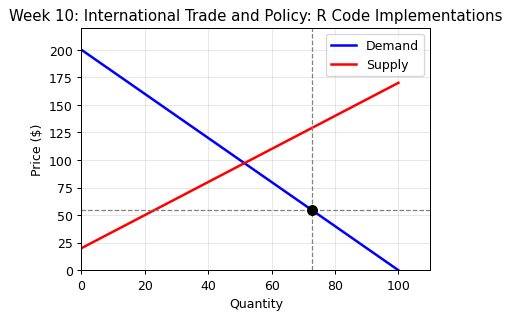

In [ ]:
# Supply & demand plot — output pre-rendered for viewer testing
P_range <- seq(0, 100, by = 0.5)
Qd <- 200 - 2 * P_range
Qs <- 20 + 1.5 * P_range
plot(Qd, P_range, type='l', col='blue', lwd=2,
     xlab='Quantity', ylab='Price', main='Supply & Demand')
lines(Qs, P_range, col='red', lwd=2)
legend('topright', c('Demand','Supply'), col=c('blue','red'), lty=1)

## Viewer Test: Empty Cell

The cell below is intentionally empty — the viewer should skip it gracefully.

## Common Patterns

**Small Country Tariff**

```r
# p_domestic = p_world + t
# Calculate Q_D, Q_S at new price
# DWL = 0.5 * t * (ΔQ_S + ΔQ_D)
```

**Quota Analysis**

```r
# Find p where D(p) - S(p) = M_bar
# p_q = (a - c - M_bar) / (b + d)
# Rent = (p_q - p_w) * M_bar
```

**Large Country**

```r
# Solve: domestic imports = foreign exports
# With tariff: p_d = p_w + t
# Foreign supply responds to p_w, not p_d
```

## Debugging Tips

| Error | Cause | Fix |
|-------|-------|-----|
| `Negative imports calculated` | Country is actually an exporter at this price | Check if p_w > p_autarky; if so, calculate exports instead |
| `Tariff revenue is zero` | Prohibitive tariff eliminated all imports | Check if p_w + t > autarky price |
| `Quota price below world price` | Quota larger than free trade imports | Quota only binds if M_bar < free trade imports |